# 4. Resultaten

Voor het runnen van dit hoofdstuk moet eerst Belangrijkstecodes.ipynb gerund worden. 

## 4.1. Kalibratie en validatie van gemodelleerde Lobith-afvoer
Het wflow-model is gekalibreerd door middel van een handmatige parameterafstelling. Hierbij zijn verschillende parametercombinaties getest en beoordeeld op basis van de overeenkomst tussen de gesimuleerde afvoer bij Lobith en de GRDC-waarnemingen. De uiteindelijke parameterinstelling bestaat uit
een PET-schaalfactor van 0,90, een vermenigvuldigingsfactor van 1,25 voor de CanopyGapFraction,
een factor 2,00 voor de Manning-ruwheidscoëfficiënt van het rivierkanaal en een factor 1,25 voor de
Manning-ruwheidscoëfficiënt van het landoppervlakte buiten het rivierkanaal. Deze combinatie is geselecteerd omdat deze in de kalibratieperiode de beste balans gaf tussen een lage bias, een verbeterde
log-NSE en een realistischere weergave van lage afvoeren. Dezelfde parameterinstelling is vervolgens
gebruikt voor de historische validatieperiode en voor de toekomstscenario’s SSP1-2.6, SSP2-4.5 en
SSP5-8.5, zodat verschillen tussen de scenario’s niet worden veroorzaakt door veranderende modelparameters.

## Algemede code voor hoofdstuk 4

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_dir = Path("/home/niels/BEP-Niels")
repo_dir = project_dir / "book" / "thesis_projects" / "BSc" / "2026_Q4_NielsEijer_CEG"
bestanden_dir = repo_dir / "Bestanden"

results_dir = project_dir / "results"
temp_dir = project_dir / "temp_runs"
cmip_dir = results_dir / "CMIP_delta_change"
figures_dir = project_dir / "figures"
rhine_dir = bestanden_dir / "Rhine"

figures_dir.mkdir(exist_ok=True)

In [17]:
def fdc_values(series):
    values = np.sort(series.dropna().values)[::-1]
    exceedance = np.arange(1, len(values) + 1) / (len(values) + 1) * 100
    return exceedance, values


def find_lowflow_events(data, discharge_col, threshold):
    data = data.copy().sort_values("date")
    data["below_threshold"] = data[discharge_col] < threshold

    events = []
    current_start = None
    current_length = 0
    previous_date = None

    for _, row in data.iterrows():
        if row["below_threshold"]:
            if current_start is None:
                current_start = row["date"]
                current_length = 1
            else:
                current_length += 1
        else:
            if current_start is not None:
                events.append({
                    "start_date": current_start,
                    "end_date": previous_date,
                    "duration_days": current_length
                })
                current_start = None
                current_length = 0

        previous_date = row["date"]

    if current_start is not None:
        events.append({
            "start_date": current_start,
            "end_date": previous_date,
            "duration_days": current_length
        })

    return pd.DataFrame(events)

In [18]:
historical_file = bestanden_dir / "lobith_1986_2019_biascorrected.csv"
scores_file = bestanden_dir / "lobith_1986_2019_biascor_scores.csv"
relation_file = bestanden_dir / "lobith_four_season_qm_relation.csv"

historical = pd.read_csv(historical_file)
historical["date"] = pd.to_datetime(historical["date"])

bias_scores = pd.read_csv(scores_file)
four_relation = pd.read_csv(relation_file)

## 4.1 Kalibratie en validatie van gemodelleerde Lobith-afvoer

Het wflow-model is gekalibreerd door middel van een handmatige parameterafstelling. Hierbij zijn verschillende parametercombinaties getest en beoordeeld op basis van de overeenkomst tussen de gesimuleerde afvoer bij Lobith en de GRDC-waarnemingen. De uiteindelijke parameterinstelling bestaat uit een PET-schaalfactor van 0,90, een vermenigvuldigingsfactor van 1,25 voor de CanopyGapFraction, een factor 2,00 voor de Manning-ruwheidscoëfficiënt van het rivierkanaal en een factor 1,25 voor de Manning-ruwheidscoëfficiënt van het landoppervlakte buiten het rivierkanaal. Deze combinatie is geselecteerd omdat deze in de kalibratieperiode de beste balans gaf tussen een lage bias, een verbeterde log-NSE en een realistischere weergave van lage afvoeren. Dezelfde parameterinstelling is vervolgens gebruikt voor de historische validatieperiode en voor de toekomstscenario’s SSP1-2.6, SSP2-4.5 en SSP5-8.5, zodat verschillen tussen de scenario’s niet worden veroorzaakt door veranderende modelparameters.

**Tabel 4.1: Uiteindelijke parameterinstellingen van de gekalibreerde wflow-run.**

In [19]:
tabel_4_1 = pd.DataFrame([
    {
        "Parameter": "PET",
        "Aanpassing": "x0.90",
        "Toelichting": "Verlaging van de potentiële evapotranspiratie"
    },
    {
        "Parameter": "CanopyGapFraction",
        "Aanpassing": "x1.25",
        "Toelichting": "Aanpassing van vegetatie/interceptieprocessen"
    },
    {
        "Parameter": "N_River",
        "Aanpassing": "x2.00",
        "Toelichting": "Verhoging van de rivierkanaalruwheid"
    },
    {
        "Parameter": "N",
        "Aanpassing": "x1.25",
        "Toelichting": "Verhoging van ruwheid landoppervlak"
    },
])

tabel_4_1


,Parameter,Aanpassing,Toelichting
0,PET,x0.90,Verlaging van de potentiële evapotranspiratie
1,CanopyGapFraction,x1.25,Aanpassing van vegetatie/interceptieprocessen
2,N_River,x2.00,Verhoging van de rivierkanaalruwheid
3,N,x1.25,Verhoging van ruwheid landoppervlak


De ongecorrigeerde wflow-output laat over de volledige analyseperiode een stevige systematische overschatting zien ten opzichte van de GRDC-meetreeks. De gemiddelde bias bedraagt ruim 1.150 m3/s en de RMSE ligt boven de 2.000 m3/s. De log-NSE van -0,60 op de kalibratieperiode en -1,22 op de validatieperiode geeft aan dat het ruwe model de lage afvoerverdeling niet goed reproduceert. Dit maakt directe inzet van de ruwe modeloutput voor een laagwateranalyse ongeschikt.

Na toepassing van de vier-seizoens FDC-biascorrectie verbetert het beeld aanzienlijk. Tabel 4.2 geeft een overzicht van de prestatie-indicatoren voor de gecorrigeerde modeloutput op zowel de kalibratie- als de validatieperiode. Over de kalibratieperiode (1987-2003) is de bias nagenoeg 0 (+0,29 m3/s), de RMSE daalt naar 575,73 m3/s en de log-NSE bereikt 0,73. Het gecorrigeerde model telt over de kalibratieperiode 3 dagen meer onder de OLA-drempel van 1.020 m3/s, wat overeenkomt met minder dan 0,2 dag per jaar.

**Tabel 4.2: Prestatie-indicatoren van de vier-seizoens FDC-biascorrectie voor de kalibratie- en validatieperiode. Bias en RMSE zijn uitgedrukt in m3/s. Diff. < 1020 en diff. < 1600 geven het verschil in aantal dagen (model - GRDC) aan.**

In [20]:
period_labels = {
    "calibration_1987_2003": "Kalibratie 1987-2003",
    "validation_2004_2019": "Validatie 2004-2019",
    "validation_2004_2010": "Validatie 2004-2010",
    "validation_2011_2019": "Validatie 2011-2019",
}

selected_periods = list(period_labels.keys())

tabel_4_2 = bias_scores[
    (bias_scores["run"] == "four_season_fdc") &
    (bias_scores["period"].isin(selected_periods))
].copy()

tabel_4_2["Periode"] = tabel_4_2["period"].map(period_labels)

tabel_4_2 = tabel_4_2[[
    "Periode",
    "bias",
    "rmse",
    "log_nse",
    "diff_days_below_1020",
    "diff_days_below_1600"
]].rename(columns={
    "bias": "Bias (m3/s)",
    "rmse": "RMSE (m3/s)",
    "log_nse": "Log-NSE",
    "diff_days_below_1020": "Diff. < 1020 (d)",
    "diff_days_below_1600": "Diff. < 1600 (d)",
})

tabel_4_2

,Periode,Bias (m3/s),RMSE (m3/s),Log-NSE,Diff. < 1020 (d),Diff. < 1600 (d)
3,Kalibratie 1987-2003,0.29,575.73,0.73,3,6
7,Validatie 2004-2019,125.91,557.78,0.66,43,-131
11,Validatie 2004-2010,179.80,549.45,0.54,54,-150
15,Validatie 2011-2019,83.99,564.18,0.73,-11,19


De validatieperiode (2004-2019) als geheel geeft een positieve bias van 126 m3/s en een log-NSE van 0,66. Het model telt 43 dagen meer onder de OLA dan de meetreeks, dat is ongeveer 2,7 dagen per jaar. Dit is aanvaardbaar voor het doel van het onderzoek: een inschatting maken van de orde van grootte van de invloed van klimaatverandering op de bevaarbaarheid van de IJssel. Een afwijking van enkele dagen per jaar heeft hierop een relatief beperkte invloed.

In figuur 4.1 zijn de gemeten GRDC-data bij Lobith en de modeloutput met vier-seizoensbiascorrectie geplot over de validatieperiode.

**Figuur 4.1: Vergelijking van de GRDC-waarnemingen, de ruwe wflow-output en de vier-seizoens biasgecorrigeerde wflow-output voor de validatieperiode 2004-2019. De bovenste figuur toont de tijdreeksen; de onderste figuur toont de bijbehorende flow duration curves. De horizontale lijnen geven de drempelwaarden van 1.600 m3/s en 1.020 m3/s bij Lobith weer.**

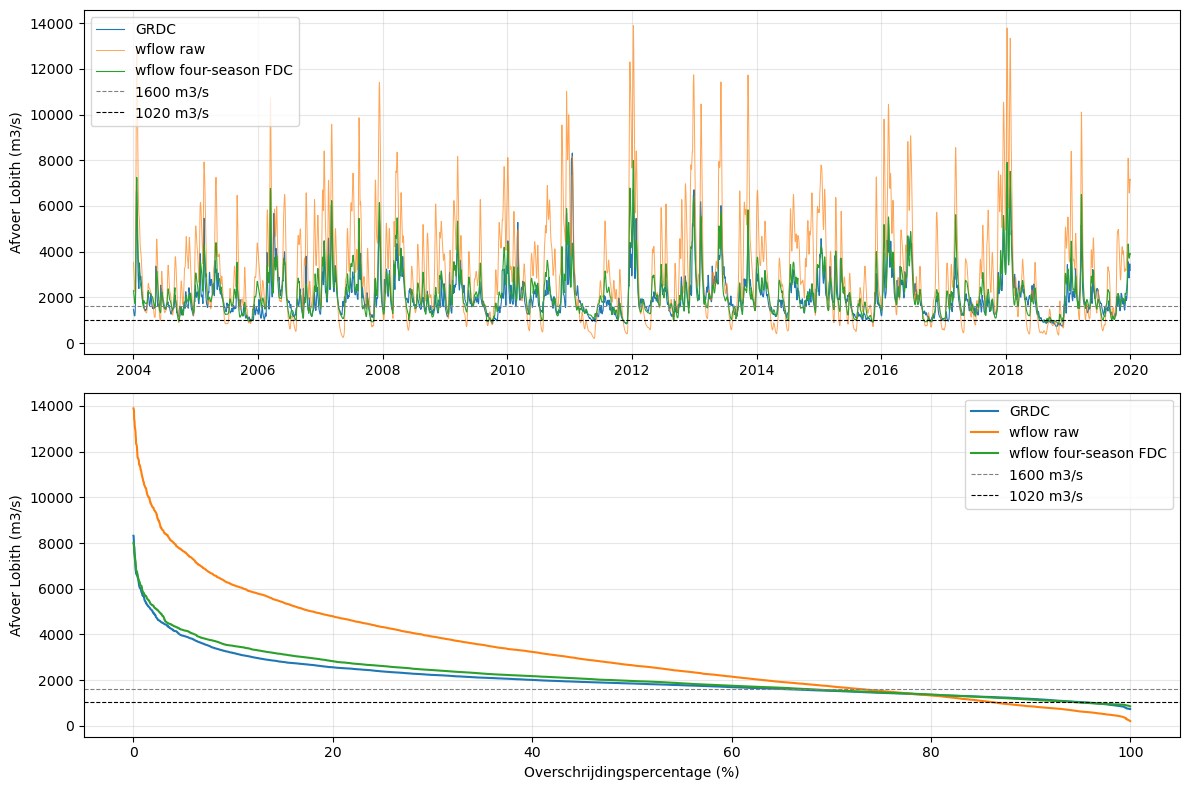

In [21]:
validation = historical[
    (historical["date"] >= "2004-01-01") &
    (historical["date"] <= "2019-12-31")
].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(
    validation["date"],
    validation["Q_grdc_m3s"],
    label="GRDC",
    linewidth=0.8
)

axes[0].plot(
    validation["date"],
    validation["Q_model_raw_m3s"],
    label="wflow raw",
    linewidth=0.7,
    alpha=0.7
)

axes[0].plot(
    validation["date"],
    validation["Q_model_four_season_fdc_m3s"],
    label="wflow four-season FDC",
    linewidth=0.8
)

axes[0].axhline(1600, linestyle="--", color="grey", linewidth=0.8, label="1600 m3/s")
axes[0].axhline(1020, linestyle="--", color="black", linewidth=0.8, label="1020 m3/s")
axes[0].set_ylabel("Afvoer Lobith (m3/s)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for label, col in {
    "GRDC": "Q_grdc_m3s",
    "wflow raw": "Q_model_raw_m3s",
    "wflow four-season FDC": "Q_model_four_season_fdc_m3s",
}.items():
    x, y = fdc_values(validation[col])
    axes[1].plot(x, y, label=label)

axes[1].axhline(1600, linestyle="--", color="grey", linewidth=0.8, label="1600 m3/s")
axes[1].axhline(1020, linestyle="--", color="black", linewidth=0.8, label="1020 m3/s")
axes[1].set_xlabel("Overschrijdingspercentage (%)")
axes[1].set_ylabel("Afvoer Lobith (m3/s)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.2 Verandering van lage-afvoercondities onder klimaatscenario's

Als historische referentie geldt de GRDC-meetreeks over 1990-2019. Het q5-percentiel bedraagt 1.057 m3/s, het q10-percentiel 1.185 m3/s en het mediane debiet (q50) 2.161 m3/s. Gemiddeld over de gehele periode valt de afvoer 14,3 dagen per jaar onder de OLA-drempel van 1.020 m3/s. Historisch zijn de meeste laagwaterdagen geconcentreerd in de herfstmaanden (september-november), met een kleinere bijdrage van de zomermaanden (juli-augustus) en incidenteel ook de wintermaanden (december-januari).

Tabel 4.3 laat zien dat de laagwatercondities richting het einde van de eeuw verslechteren, vooral onder SSP2-4.5 en SSP5-8.5. Onder SSP1-2.6 blijven de veranderingen relatief beperkt: zowel het q5- als q10-percentiel neemt licht af en het aantal dagen onder de OLA-drempel stijgt slechts beperkt ten opzichte van de GRDC-data.

Onder SSP2-4.5 en SSP5-8.5 is de verschuiving duidelijker. De lage-afvoerpercentielen dalen sterker en het gemiddelde aantal kritieke laagwaterdagen per jaar neemt significant toe. Vooral onder SSP5-8.5 is deze toename groot: het aantal dagen onder de OLA-drempel stijgt van 14,3 naar 33,5 dagen per jaar. Wanneer ook de hogere drempelwaarden van 1.133 m3/s en 1.229 m3/s worden beschouwd, neemt het aantal kritieke dagen in alle klimaatscenario’s toe.

**Tabel 4.3: Lage-afvoerpercentielen en gemiddeld aantal kritieke laagwaterdagen per jaar voor de drie drempelwaarden, per scenario.**


In [22]:
future_files = {
    "ssp126": bestanden_dir / "future_ssp126_2071_2100_lobith_daily_biascorrected.csv",
    "ssp245": bestanden_dir / "future_ssp245_2071_2100_lobith_daily_biascorrected.csv",
    "ssp585": bestanden_dir / "future_ssp585_2071_2100_lobith_daily_biascorrected.csv",
}

historical_start = "1990-01-01"
historical_end = "2019-12-31"
future_start = "2071-01-01"
future_end = "2100-12-31"
thresholds = [1020, 1133, 1229]

scenario_labels = {
    "ssp126": "SSP1-2.6 2071-2100",
    "ssp245": "SSP2-4.5 2071-2100",
    "ssp585": "SSP5-8.5 2071-2100",
}

historical_grdc = historical[
    (historical["date"] >= historical_start) &
    (historical["date"] <= historical_end)
].copy()

historical_grdc = historical_grdc[["date", "Q_grdc_m3s"]].rename(
    columns={"Q_grdc_m3s": "Q_m3s"}
)

historical_grdc["scenario"] = "Historisch GRDC 1990-2019"

future_rows = []

for scenario, file in future_files.items():
    data = pd.read_csv(file)
    data["date"] = pd.to_datetime(data["date"])

    data = data[
        (data["date"] >= future_start) &
        (data["date"] <= future_end)
    ].copy()

    data = data[["date", "Q_model_biascorrected_m3s"]].rename(
        columns={"Q_model_biascorrected_m3s": "Q_m3s"}
    )

    data["scenario"] = scenario_labels[scenario]
    future_rows.append(data)

future_all = pd.concat(future_rows, ignore_index=True)
table_data = pd.concat([historical_grdc, future_all], ignore_index=True)

rows = []

for scenario in table_data["scenario"].unique():
    scenario_data = table_data[table_data["scenario"] == scenario].copy()
    n_years = scenario_data["date"].dt.year.nunique()

    row = {
        "Scenario": scenario,
        "q5 (m3/s)": round(scenario_data["Q_m3s"].quantile(0.05)),
        "q10 (m3/s)": round(scenario_data["Q_m3s"].quantile(0.10)),
        "OLA 1020 (d/jr)": round((scenario_data["Q_m3s"] < 1020).sum() / n_years, 1),
        "10%-scen. 1133 (d/jr)": round((scenario_data["Q_m3s"] < 1133).sum() / n_years, 1),
        "17%-scen. 1229 (d/jr)": round((scenario_data["Q_m3s"] < 1229).sum() / n_years, 1),
    }

    rows.append(row)

tabel_4_3 = pd.DataFrame(rows)
tabel_4_3

,Scenario,q5 (m3/s),q10 (m3/s),OLA 1020 (d/jr),10%-scen. 1133 (d/jr),17%-scen. 1229 (d/jr)
0,Historisch GRDC 1990-2019,1057,1185,14.3,28.2,43.4
1,SSP1-2.6 2071-2100,1038,1161,15.8,32.6,45.0
2,SSP2-4.5 2071-2100,969,1084,27.4,46.8,62.7
3,SSP5-8.5 2071-2100,945,1040,33.5,54.2,70.1


**Figuur 4.2: Verdeling van jaarlijkse lage-afvoerindicatoren bij Lobith voor de historische referentieperiode en de drie klimaatscenario’s. Links is per periode het jaarlijkse q10-percentiel weergegeven, waarbij de gestreepte lijn de OLA-drempel van 1.020 m3/s aangeeft. Rechts is per periode het jaarlijkse aantal dagen onder deze OLA-drempel weergegeven. De boxplots tonen de spreiding tussen individuele jaren binnen de historische periode 1990-2019 en de toekomstscenario’s voor 2071-2100. De driehoek geeft het gemiddelde weer; losse punten geven uitschieters aan.**


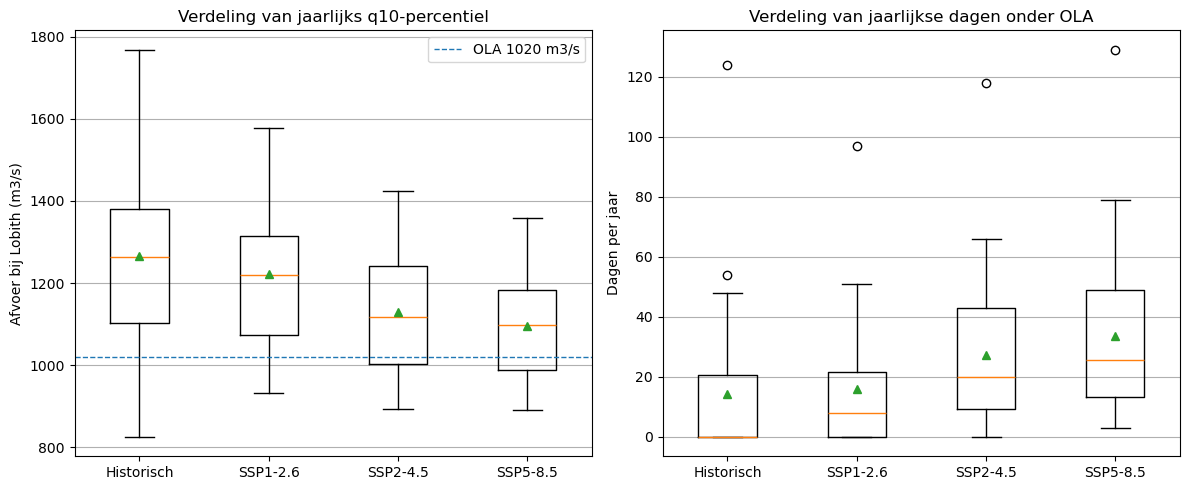

In [23]:
ola_threshold = 1020

annual_hist = historical_grdc.copy()
annual_hist["year"] = annual_hist["date"].dt.year

annual_hist = annual_hist.groupby("year").agg(
    q10_annual=("Q_m3s", lambda x: x.quantile(0.10)),
    days_below_ola=("Q_m3s", lambda x: (x < ola_threshold).sum())
).reset_index()

annual_hist["scenario"] = "Historisch"
annual_hist["period_year"] = annual_hist["year"] - annual_hist["year"].min() + 1

future_for_annual = future_all.copy()
future_for_annual["year"] = future_for_annual["date"].dt.year

annual_future = future_for_annual.groupby(["scenario", "year"]).agg(
    q10_annual=("Q_m3s", lambda x: x.quantile(0.10)),
    days_below_ola=("Q_m3s", lambda x: (x < ola_threshold).sum())
).reset_index()

annual_future["scenario"] = annual_future["scenario"].replace({
    "SSP1-2.6 2071-2100": "SSP1-2.6",
    "SSP2-4.5 2071-2100": "SSP2-4.5",
    "SSP5-8.5 2071-2100": "SSP5-8.5",
})

annual_future["period_year"] = annual_future.groupby("scenario")["year"].transform(
    lambda x: x - x.min() + 1
)

annual_all = pd.concat([annual_hist, annual_future], ignore_index=True)

plot_order = ["Historisch", "SSP1-2.6", "SSP2-4.5", "SSP5-8.5"]
q10_data = []
days_data = []

for name in plot_order:
    data = annual_all[annual_all["scenario"] == name]
    q10_data.append(data["q10_annual"])
    days_data.append(data["days_below_ola"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(q10_data, labels=plot_order, showmeans=True)
axes[0].axhline(1020, linestyle="--", linewidth=1, label="OLA 1020 m3/s")
axes[0].set_title("Verdeling van jaarlijks q10-percentiel")
axes[0].set_ylabel("Afvoer bij Lobith (m3/s)")
axes[0].grid(True, axis="y")
axes[0].legend()

axes[1].boxplot(days_data, labels=plot_order, showmeans=True)
axes[1].set_title("Verdeling van jaarlijkse dagen onder OLA")
axes[1].set_ylabel("Dagen per jaar")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()



In figuur 4.2 is de jaarlijkse verdeling van het q10-percentiel en het aantal dagen onder de OLA-drempel van 1.020 m3/s te zien. Het q10-percentiel ligt in de scenario’s SSP2-4.5 en SSP5-8.5 lager dan in de historische referentieperiode. In dezelfde scenario’s ligt ook het jaarlijkse aantal dagen onder de OLA-drempel hoger.

## 4.3 Effect van afvoerverdeling op kritieke laagwaterdagen

Tabel 4.3 toont de resultaten voor de drie drempelwaarden die corresponderen met de OLA, het 10%-scenario (1.133 m3/s) en het 17%-scenario (1.229 m3/s). Het patroon is consistent over alle drie de drempelwaarden: SSP1-2.6 geeft de kleinste toename, terwijl SSP5-8.5 de sterkste verslechtering laat zien.

De gevoeligheidsanalyse met de drie drempelscenario’s laat tevens zien dat de keuze voor de afvoerverdeling een substantiële invloed heeft op de uitkomsten. Wanneer wordt aangenomen dat de IJssel onder lage-afvoercondities 10% minder water ontvangt dan bij de huidige verdeling (1.133 m3/s-drempel), stijgt het jaarlijkse aantal kritieke laagwaterdagen onder SSP5-8.5 van 33,5 naar 54,2 dagen, een verschil van meer dan twintig dagen per jaar. Bij het 17%-scenario loopt dit op tot 70,1 dagen per jaar, bijna twee keer zoveel als het historische gemiddelde bij de OLA-drempel.

De code voor dit onderdeel is dezelfde code als bij Tabel 4.3, omdat de drie drempelwaarden direct in die tabel zijn opgenomen.

## 4.4 Duur van aaneengesloten kritieke laagwaterperioden

Naast het aantal kritieke dagen is ook de duur van aaneengesloten perioden laagwater een relevante maatstaf voor bevaarbaarheidsrisico’s. Langere ononderbroken perioden onder de OLA-drempel zijn operationeel bezwaarlijker dan een gelijk aantal verspreide dagen. Tabel 4.4 geeft een overzicht van aaneengesloten perioden onder de drempelwaarde. Wat opvalt, is de waarde van 86 aaneengesloten dagen voor de GRDC-data. Dit is een hele extreme uitschieter die niet vaak voorkomt en te verklaren is door de extreme droogte in 2018. Het langste event daarna geeft een duur van 38 dagen.

**Tabel 4.4: Statistieken van aaneengesloten kritieke laagwaterperioden bij de OLA-drempel van 1.020 m3/s. Gem. = gemiddelde periode-duur, Med. = mediaan, Max. = langste aaneengesloten periode.**


In [24]:
threshold = 1020

event_summary_rows = []
all_events = []

historical_events = find_lowflow_events(
    data=historical_grdc,
    discharge_col="Q_m3s",
    threshold=threshold
)

historical_events["Scenario"] = "Historisch GRDC 1990-2019"
all_events.append(historical_events)

event_summary_rows.append({
    "Scenario": "Historisch GRDC 1990-2019",
    "Aantal events": len(historical_events),
    "Gem. (d)": round(historical_events["duration_days"].mean(), 1),
    "Mediaan (d)": historical_events["duration_days"].median(),
    "Max. (d)": int(historical_events["duration_days"].max())
})

for scenario in ["SSP1-2.6 2071-2100", "SSP2-4.5 2071-2100", "SSP5-8.5 2071-2100"]:
    future_scenario = future_all[future_all["scenario"] == scenario].copy()

    future_events = find_lowflow_events(
        data=future_scenario,
        discharge_col="Q_m3s",
        threshold=threshold
    )

    future_events["Scenario"] = scenario
    all_events.append(future_events)

    event_summary_rows.append({
        "Scenario": scenario,
        "Aantal events": len(future_events),
        "Gem. (d)": round(future_events["duration_days"].mean(), 1),
        "Mediaan (d)": future_events["duration_days"].median(),
        "Max. (d)": int(future_events["duration_days"].max())
    })

tabel_4_4 = pd.DataFrame(event_summary_rows)
tabel_4_4

,Scenario,Aantal events,Gem. (d),Mediaan (d),Max. (d)
0,Historisch GRDC 1990-2019,35,12.3,8.0,86
1,SSP1-2.6 2071-2100,34,13.9,9.5,51
2,SSP2-4.5 2071-2100,52,15.8,10.0,55
3,SSP5-8.5 2071-2100,57,17.6,12.0,120


Onder SSP5-8.5 neemt niet alleen het aantal events toe, maar ook de maximale duur van één aaneengesloten kritieke laagwaterperiode. De langste periode onder 1.020 m3/s bedraagt in dit SSP5-8.5 120 dagen, tegenover 38 dagen in de historische referentie.

## 4.5 Vergelijking tussen klimaatscenario's

De drie klimaatscenario’s laten een duidelijk geordende respons zien: meer opwarming en hogere emissies gaan gepaard met een sterkere verslechtering van de lage afvoercondities. SSP1-2.6 wijkt relatief weinig af van de historische situatie; SSP2-4.5 en SSP5-8.5 tonen een substantiële verslechtering. Dit patroon is zichtbaar in zowel de lage afvoerpercentielen als het aantal kritieke laagwaterdagen.

Onder SSP1-2.6 nemen het q5- en q10-percentiel slechts beperkt af en stijgt het aantal dagen onder de OLA-drempel licht. Onder SSP2-4.5 en SSP5-8.5 dalen de lage-afvoerpercentielen sterker en neemt het aantal kritieke dagen onder de OLA-drempel duidelijk toe. Vooral SSP5-8.5 vormt hierbij een zeer ongunstig scenario met een toename van 134%.

De codebasis voor deze vergelijking bestaat uit Tabel 4.3 en Figuur 4.2. De scenariovolgorde en de gebruikte variabele zijn:

In [25]:
plot_order = ["Historisch", "SSP1-2.6", "SSP2-4.5", "SSP5-8.5"]
discharge_col = "Q_m3s"
thresholds = [1020, 1133, 1229]

scenario_comparison = tabel_4_3[[
    "Scenario",
    "OLA 1020 (d/jr)",
    "10%-scen. 1133 (d/jr)",
    "17%-scen. 1229 (d/jr)"
]].copy()

display(scenario_comparison)

,Scenario,OLA 1020 (d/jr),10%-scen. 1133 (d/jr),17%-scen. 1229 (d/jr)
0,Historisch GRDC 1990-2019,14.3,28.2,43.4
1,SSP1-2.6 2071-2100,15.8,32.6,45.0
2,SSP2-4.5 2071-2100,27.4,46.8,62.7
3,SSP5-8.5 2071-2100,33.5,54.2,70.1


## 4.6 Samenvatting van de belangrijkste resultaten

De vergelijking tussen de gemodelleerde afvoeren en de gemeten afvoer bij Lobith laat zien dat de ongecorrigeerde wflow-output de afvoer duidelijk overschat. Over de volledige analyseperiode bedraagt de gemiddelde bias ruim 1.150 m3/s en ligt de RMSE boven de 2.000 m3/s. Ook de log-NSE is negatief, met waarden van -0,60 in de kalibratieperiode en -1,22 in de validatieperiode. Na de toepassing van de seizoensgerelateerde biascorrectie verandert dit beeld: in de kalibratieperiode komt de bias uit op +0,29 m3/s, met een RMSE van +575,9 m3/s en een log-NSE van 0,73. De onafhankelijke validatieperiode geeft de bias een score van +125,9 m3/s, de RMSE 557,8 m3/s, en de log-NSE 0,66. Voor het aantal dagen onder de OLA-drempel van 1.020 m3/s telt het gecorrigeerde model in de validatieperiode 43 dagen meer dan de GRDC-reeks over dezelfde periode (2004-2019).

Voor de historische referentieperiode 1990-2019 bedraagt het q5-percentiel van de GRDC-afvoer 1.057 m3/s en het q10-percentiel 1.185 m3/s. Deze lage afvoerpercentielen liggen in de toekomstscenario’s lager dan in de historische referentieperiode. Het q5-percentiel daalt naar 1.038 m3/s onder SSP1-2.6, 969 m3/s onder SSP2-4.5 en 945 m3/s onder SSP5-8.5. Het q10-percentiel daalt naar 1.161 m3/s onder SSP1-2.6, 1.084 m3/s onder SSP2-4.5 en 1.040 m3/s onder SSP5-8.5.

Gemiddeld ligt de afvoer in de historische periode 14,3 dagen per jaar onder de OLA-drempel van 1.020 m3/s. In de toekomstscenario’s neemt dit aantal toe. Onder SSP1-2.6 blijft de verandering beperkt en komt het gemiddelde uit op 15,8 dagen per jaar en onder SSP5-8.5 stijgt dit naar iets meer dan 33,5 dagen per jaar.

Naast de vaste OLA-drempel is er ook gekeken naar twee hogere drempelwaarden, waarmee de gevoeligheid voor veranderende afvoerverdelingen richting de IJssel is meegenomen. Bij de 10%-variant (drempelwaarde van 1.133 m3/s) bedraagt het historische gemiddelde 28,2 kritieke dagen per jaar; onder SSP1-2.6, SSP2-4.5 en SSP5-8.5 loopt dit op tot respectievelijk 32,6, 46,8 en 54,2 dagen per jaar. Voor de 17%-variant is het historische gemiddelde 43,4 dagen per jaar. Voor de modellering loopt dit voor SSP1-2.6, SSP2-4.5 en SSP5-8.5 op tot respectievelijk 45,0, 62,7 en 70,1 dagen per jaar.

Tot slot is er gekeken naar de duur van aaneengesloten perioden waarin de afvoer onder de OLA-drempel van 1.020 m3/s ligt. In de historische referentie zijn er 35 van zulke perioden gevonden. Deze hebben een gemiddelde duur van 12,3 dagen, en een maximale duur van 38 dagen wanneer de extreme uitschieter van 86 dagen apart wordt beschouwd. Onder SSP1-2.6 gaat het om 34 perioden, met een gemiddelde duur van 13,9 dagen en een maximale duur van 51 dagen. Onder SSP2-4.5 neemt het aantal perioden toe naar 52, met een gemiddelde duur van 15,8 dagen, en een maximale duur van 55 dagen. Onder SSP5-8.5 worden 57 perioden gevonden. Deze duren gemiddeld 17,6 dagen, en maximaal 120 dagen.
